# Horse Racing Analytics Project
This notebook demonstrates data cleaning, EDA, feature engineering, prediction modeling, probability scoring, fair odds, ROI backtesting, and AI explanations.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score


## Load Dataset

In [3]:
# Save your dataset as horse_racing.csv in the same folder
df = pd.read_csv('horses_1991 (1).csv')
df.head()

,rid,horseName,age,saddle,decimalPrice,isFav,trainerName,jockeyName,position,positionL,...,TR,OR,father,mother,gfather,runners,margin,weight,res_win,res_place
0,272927,Strong Suspicion,7.0,0.0,0.222222,1,A L T Moore,P L Malone,1,NaN,...,NaN,NaN,Strong Gale,Shady Doorknocker,Mon Capitaine,13,1.431524,69,1.0,1
1,272927,Baltray,10.0,0.0,0.066667,0,J T R Dreaper,K Morgan,2,2.5,...,NaN,NaN,Hardboy,Unsinkable Sarah,Mon Capitaine,13,1.431524,73,0.0,1
2,272927,Mister Chatterbox,10.0,0.0,0.166667,0,J R H Fowler,D P Fagan,3,10,...,NaN,NaN,Le Bavard,Farthest South,Shackleton,13,1.431524,70,0.0,1
3,272927,Culleendubh,11.0,0.0,0.111111,0,S F Maye,G Kilfeather,4,10,...,NaN,NaN,Bonne Noel,Har Valley,Harwell,13,1.431524,73,0.0,0
4,272927,Calliealla,6.0,0.0,0.066667,0,M Keane,A Powell,5,dist,...,NaN,NaN,Callernish,Shady Ahan,Mon Capitaine,13,1.431524,64,0.0,0


## Data Cleaning

In [4]:
df.columns = df.columns.str.strip()
df.replace(['', 'dist'], np.nan, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89693 entries, 0 to 89692
Data columns (total 27 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   rid           89693 non-null  int64  
 1   horseName     89693 non-null  object 
 2   age           89635 non-null  float64
 3   saddle        89690 non-null  float64
 4   decimalPrice  89693 non-null  float64
 5   isFav         89693 non-null  int64  
 6   trainerName   89520 non-null  object 
 7   jockeyName    89691 non-null  object 
 8   position      89693 non-null  int64  
 9   positionL     56297 non-null  object 
 10  dist          64123 non-null  object 
 11  weightSt      89693 non-null  int64  
 12  weightLb      89693 non-null  int64  
 13  overWeight    4546 non-null   float64
 14  outHandicap   4424 non-null   float64
 15  headGear      9691 non-null   object 
 16  RPR           33617 non-null  float64
 17  TR            47098 non-null  float64
 18  OR            32274 non-nu

## Exploratory Data Analysis

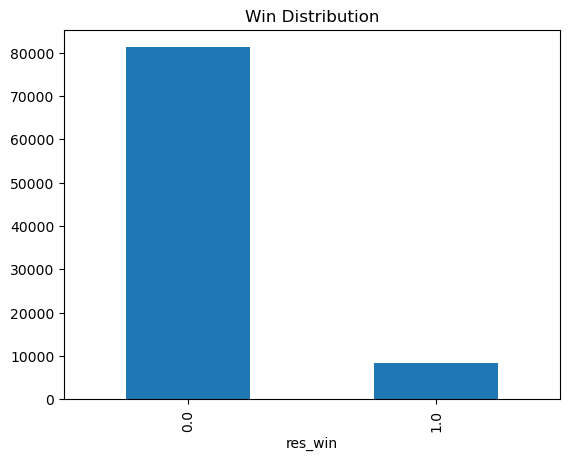

In [5]:
df['res_win'].value_counts().plot(kind='bar')
plt.title('Win Distribution')
plt.show()

## Feature Engineering

In [7]:
df['total_weight'] = df['weightSt'].fillna(0)*14 + df['weightLb'].fillna(0)
features = ['age','decimalPrice','isFav','runners','total_weight','trainerName','jockeyName','father']
target = 'res_win'

## Build Prediction Model

In [9]:
X = df[features]
y = df[target]
cat_cols = X.select_dtypes(include='object').columns
num_cols = X.select_dtypes(exclude='object').columns

preprocessor = ColumnTransformer([
 ('num', SimpleImputer(strategy='median'), num_cols),
 ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                  ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_cols)
])

model = Pipeline([
 ('prep', preprocessor),
 ('rf', RandomForestClassifier(n_estimators=200, random_state=42))
])

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
model.fit(X_train,y_train)
pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:,1]

print('Accuracy:', accuracy_score(y_test,pred))

Accuracy: 0.9049556831484475


## Probability & Fair Odds

In [10]:
results = X_test.copy()
results['win_probability'] = prob
results['fair_odds'] = 1 / np.clip(prob,0.01,None)
results[['win_probability','fair_odds']].head()

,win_probability,fair_odds
85069,0.040,25.000000
24385,0.150,6.666667
19869,0.030,33.333333
81368,0.135,7.407407
33964,0.015,66.666667


## ROI Backtesting

In [11]:
results['bet'] = (results['win_probability'] > 0.5).astype(int)
results['stake'] = results['bet']
results['profit'] = np.where(results['bet']==1, results.get('decimalPrice',1), 0)
roi = (results['profit'].sum()-results['stake'].sum()) / max(results['stake'].sum(),1)
print('ROI:', roi)

ROI: -0.48301850067625085


## AI Race Explanation

In [12]:
def explain(horse, prob):
    return f'{horse} has a {prob:.1%} predicted win probability based on age, odds, trainer, jockey and historical race signals.'

print(explain('Strong Suspicion',0.72))

Strong Suspicion has a 72.0% predicted win probability based on age, odds, trainer, jockey and historical race signals.
